## 5차시 과제

**Q1. Feature Extraction과 Feature Selection 각각을 설명하고, 차이점을 서술해주세요. (7점)**

### Feature Extraction
원본 데이터셋에서 유용한 정보를 추출하여 새로운, 더 유의미한 feature로 변환

### Feature Selection
주어진 feature 중에서 필요한 feature만을 선택

### 차이점
 Feature Extraction은 피처를 변경하거나 새로운 피처를 만드는 것이지만 Feature Selection은 필요한 피처만 선택하므로 일부 피처를 제거한다



**Q2. Feature Selection의 네가지 방법에 대해 짧게 설명하고, 각각의 수행 방법을 가능한 PDF에 없는 것으로 서술해주세요. (각 4점, 총 16점)**

### Filter Method
feature들의 통계적 속성을 기반으로 feature를 선택하는 방법
- 통계적 측정 방법을 바탕으로 feature 간 상관관계를 알아낸 뒤, 높은 상관계수(영향력)을 가지는 feature를 선택
- 유전자 알고리즘: 여러 세대에 걸쳐 특성을 평가하고, 최적의 조합을 찾아냄


### Wrapper Method
feature의 부분 집합을 사용하여 모델의 성능을 평가하고 최적의 feature 집합을 선택하는 방법
- 예측 정확도 측면에서 가장 좋은 성능을 보이는 feature subset을 뽑아내는 방법
- AIC/BIC 기준: 각 특성 조합에 대해 AIC 또는 BIC 값을 계산하고, 가장 낮은 값을 가진 조합을 선택


### Embedded Method
모델 자체에서 feature를 선택하는 방법으로, L1 정규화 기법 등을 사용하여 feature를 선택하거나 가중치를 줄이는 방식
- 앞의 두 방식의 장점을 결합한 방법, 각각의 feature를 직접 학습하여 모델의 정확도에 기여하는 feature를 선택  
- XGBoost: 일반적인 Gradient Boosting 알고리즘을 개선한 라이브러리로, 안정적인 성능을 제공  
  트리를 생성할 때, 각 노드에서 최적의 분할을 찾기 위해 모든 데이터를 사용  
  정규화(regularization) 기능이 내장되어 있어 과적합을 방지하는 데 유리

### eXplainable AI
인공지능 모델의 결정 과정을 이해하고 설명할 수 있는 AI 기술
- 모델 및 feature에 대한 이해를 바탕으로 feature selection을 진행
- LIME (Local Interpretable Model-agnostic Explanations): 특정 예측에 대해 모델의 로컬 근처에서 간단한 모델을 학습하여 설명


**Q3. 기여도와 피처 중요도 각각을 설명하고, 차이점을 서술해주세요. (10점)**

### 기여도
특정 피처가 모델의 예측에 미치는 영향을 수치적으로 나타내는 방법  
모델의 예측을 구성하는 각 피처의 상대적인 영향을 측정  

### 피처 중요도
모델이 예측을 수행하는 데 있어 각 피처의 중요성을 평가하는 지표  
모델의 성능에 기여하는 정도를 수치적으로 표현  

### 차이점
기여도는 특정 예측에 대한 피처의 영향을 측정하지만, 피처 중요도는 모델 전체에서 피처의 중요성을 평가함


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import klib
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

#ignore warningss
import warnings
warnings.filterwarnings('ignore')

bike_df = pd.read_csv('data/bike_df.csv')

X = bike_df.iloc[:, :-1]
y = bike_df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1004)

**Q4. klib 라이브러리를 활용하여 종속변수와 독립변수 간의 상관관계를 시각화(7점)를 통해 확인한 후,  
제거를 고려해도 될 변수와 타당한 이유를 설명해주세요. (5점, 총 12점)**  

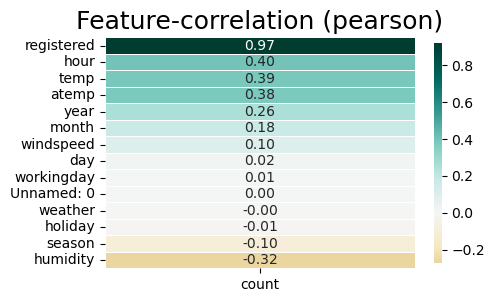

In [17]:
klib.corr_plot(data = X,
               target = y ,
               figsize = (5, 3))

plt.show() 

먼저 Unnamed: 0이라는 피처는 그저 인덱스와 같은 값이므로 제거를 해도 된다. 하지만 다른 값들은 상관관계는 낮더라도 날씨, 풍속, 휴일, 주말 등에 따라 타겟값이 바뀔수 있으므로 제거 하지않는 것이 좋을 거 같다.

**기본 성능 확인 - 0.7642**

In [18]:
bike_df.columns

Index(['Unnamed: 0', 'year', 'month', 'day', 'hour', 'season', 'holiday',
       'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed',
       'registered', 'count'],
      dtype='object')

In [19]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

boston_df = pd.read_csv('data/boston.csv')

X = boston_df.iloc[:, :-1]
y = boston_df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1004)

model = Ridge()
model.fit(X_train, y_train)

print(model.score(X_test, y_test)) 

0.7642652321370977


**Q5. 최대한 실습 파일에서 사용하였던 코드를 사용하지 않고, 새로운 두가지 방법을 수행하여 피처를 최종 선택하고 타당한 이유를 설명해주세요. (각 12점)**  
너무 어렵다면 실습 파일 코드를 사용하셔도 됩니다 :)

In [20]:
boston_df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


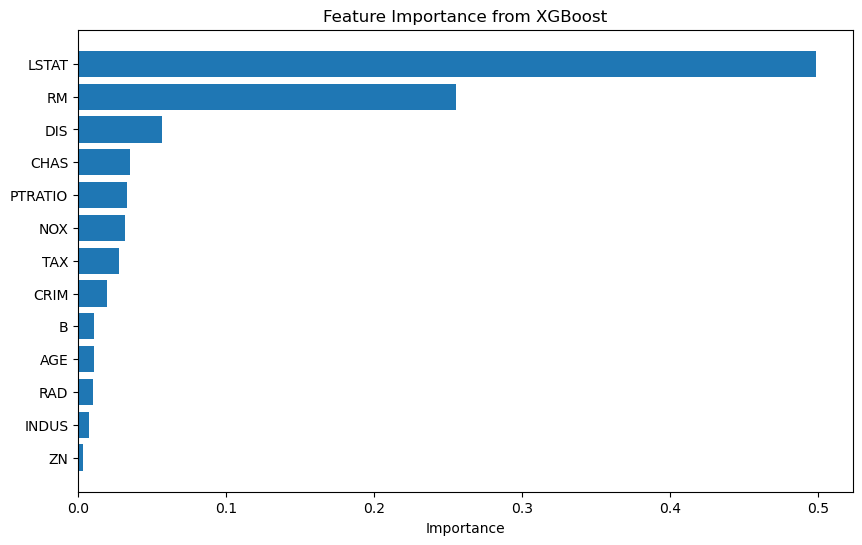

Index(['RAD', 'AGE', 'B', 'CRIM', 'TAX', 'NOX', 'PTRATIO', 'CHAS', 'DIS', 'RM',
       'LSTAT'],
      dtype='object')

In [43]:
# 1) XGBoost
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
xgb_model.fit(X_train, y_train)

# 피처 중요도 추출
importance = xgb_model.feature_importances_
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importance})
importance_df = importance_df.sort_values(by='Importance')

# 중요 피처 시각화
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance from XGBoost')
plt.show()

selected_features = importance_df[importance_df['Importance'] > 0.01]['Feature'].values
X_train_selected1 = X_train[selected_features]
X_test_selected1 = X_test[selected_features]
X_train_selected1.columns

In [64]:
# 2) ElasticNet
from sklearn.linear_model import ElasticNet
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
elastic.fit(X_train, y_train)

# 선택된 피처 확인 (계수가 0이 아닌 피처들)
selected_features = [feature for feature, coef in zip(X.columns, elastic.coef_) if coef != 0]

# 선택된 피처를 사용하여 데이터 프레임 재구성
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

X_train_selected.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'RM', 'DIS', 'RAD', 'TAX', 'PTRATIO',
       'B', 'LSTAT'],
      dtype='object')

In [65]:
final_features  = X_train_selected.columns[X_train_selected.columns.isin(X_train_selected1.columns)]
X_train_new = X_train[final_features]
X_test_new = X_test[final_features]
final_features

Index(['CRIM', 'CHAS', 'RM', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT'], dtype='object')

위에서 두가지 방법으로 뽑은 피처들중 공통으로 들어가 있는 'CRIM', 'CHAS', 'RM', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT'를 채택한다.

**Q6. Grid Search를 통해 하이퍼파라미터 최적화 값을 출력해주세요. (14점)**   
조정할 하이퍼파라미터: alpha, solver, max_iter, tol

In [73]:
##릿지모델사용

model = Ridge()
param_grid = {
    'alpha': [0.1, 0.5, 1.0, 5.0, 10.0],  # 규제 강도
    'solver': ['auto', 'saga', 'lsqr'], 
    'max_iter': [100, 500, 1000, 2000],  # 최대 반복 횟수
    'tol': [1e-4, 1e-3, 1e-2],  # 허용 오차
}
                 
gcv = GridSearchCV(model,                # 모델
                   param_grid = param_grid, # 탐색할 파라미터들을 딕셔너리 형태로
                   cv = 3,                  # 교차 검증 폴드 수
                   scoring = 'r2',    # 성능 평가 지표 - 정확도
                   n_jobs = -1)             # 컴퓨터의 모든 코어 사용

gcv.fit(X_train_new, y_train)

print('final params', gcv.best_params_)   # 최적의 파라미터 값 출력
print('best score', gcv.best_score_)      # 최고의 점수
print(gcv.score(X_test_new, y_test))   

final params {'alpha': 0.1, 'max_iter': 100, 'solver': 'lsqr', 'tol': 0.0001}
best score 0.7030583639549315
0.7304729664185229


In [72]:
###스태킹모델 사용

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import StackingRegressor

# 개별 모델 생성
elasticnet_model = ElasticNet(random_state=42)
xgboost_model = XGBRegressor(random_state=42)

# 두 모델 함께 사용하기 위한 스태킹 모델 생성
stacked_model = StackingRegressor(
    estimators=[
        ('elasticnet', elasticnet_model),
        ('xgboost', xgboost_model)
    ],
    final_estimator=ElasticNet()  # 예측하려는 메타모델
)

#스태킹 모델을 쓸때 변수지정 시 아래와 같이 '메타모델의 이름__'을 써야함
param_grid = {
    'final_estimator__alpha': [0.1, 0.5, 1.0, 5.0, 10.0],  # 규제 강도
    'final_estimator__max_iter': [100, 500, 1000, 2000],  # 최대 반복 횟수
    'final_estimator__tol': [1e-4, 1e-3, 1e-2],  # 허용 오차
    'final_estimator__l1_ratio': [0.1, 0.5, 0.9]  # ElasticNet의 L1 비율
}
                 
gcv = GridSearchCV(stacked_model,                # 모델
                   param_grid = param_grid, # 탐색할 파라미터들을 딕셔너리 형태로
                   cv = 3,                  # 교차 검증 폴드 수
                   scoring = 'r2',    # 성능 평가 지표 - 정확도
                   n_jobs = -1)             # 컴퓨터의 모든 코어 사용

gcv.fit(X_train_new, y_train)

print('final params', gcv.best_params_)   # 최적의 파라미터 값 출력
print('best score', gcv.best_score_)      # 최고의 점수
print(gcv.score(X_test_new, y_test))   

final params {'final_estimator__alpha': 1.0, 'final_estimator__l1_ratio': 0.9, 'final_estimator__max_iter': 100, 'final_estimator__tol': 0.0001}
best score 0.8768600561105077
0.8403774582234214


**Q7. Bayesian Optimization을 통해 성능을 출력해주세요. (17점)**   
조정할 하이퍼파라미터: alpha, solver, max_iter, tol 중 두가지 / n_iter = 20 이상

In [90]:
from bayes_opt import BayesianOptimization

# Step1. 탐색하고 싶은 하이퍼파라미터의 범위를 dictionary 형태로 지정
pbounds = {'alpha': (0.1, 10.0),  # 규제 강도
           'max_iter': (100, 2000)}

# Step2. 1에서 생성한 dictionary의 key를 arguments로 하는 함수 생성 - Surrogate Model
def elastic_opt(alpha, max_iter):

    # Step3. 탐색하고 싶은 하이퍼파라미터의 조건 지정
    params = {
        'alpha' : alpha,
        'max_iter' : int(round(max_iter))
    }
    
    # Step4. 모델 생성
    en_model = ElasticNet(**params)
    en_model.fit(X_train_new, y_train)
    
    # Step5. 최대화하려는 score 선언
    score = en_model.score(X_test_new, y_test)  # R^2 score
    
    return score

# Step6. BayesianOptimization 객체 생성
BO_el = BayesianOptimization(f = elastic_opt, pbounds = pbounds, random_state = 42) # 최대화하려는 함수 f, 탐색범위 pbounds

# Step7. 최대화
BO_el.maximize(init_points = 5, n_iter = 25) # init_points: 처음 탐색 횟수, n_iter: 추가 탐색 횟수 


|   iter    |  target   |   alpha   | max_iter  |
-------------------------------------------------
| 1         | 0.645     | 3.808     | 1.906e+03 |
| 2         | 0.6065    | 7.347     | 1.237e+03 |
| 3         | 0.6863    | 1.645     | 396.4     |
| 4         | 0.7135    | 0.675     | 1.746e+03 |
| 5         | 0.6188    | 6.051     | 1.445e+03 |
| 6         | 0.6819    | 1.835     | 1.747e+03 |
| 7         | 0.6866    | 1.63      | 1.743e+03 |
| 8         | 0.6234    | 5.562     | 396.6     |
| 9         | 0.7006    | 1.075     | 400.2     |
| 10        | 0.7255    | 0.3899    | 403.8     |
| 11        | 0.6896    | 1.502     | 407.0     |
| 12        | 0.6425    | 3.979     | 404.0     |
| 13        | 0.723     | 0.4475    | 410.3     |
| 14        | 0.6844    | 1.723     | 412.7     |
| 15        | 0.6669    | 2.524     | 409.6     |
| 16        | 0.7038    | 0.9646    | 404.9     |
| 17        | 0.7311    | 0.2689    | 391.0     |
| 18        | 0.7115    | 0.7288    | 388.6     |


In [91]:
# 하이퍼파라미터의 결과값을 불러와 "max_params"라는 변수에 저장
max_params = BO_el.max['params']
print(max_params)

max_params['alpha'] = round(max_params['alpha'], 2)
max_params['max_iter'] = round(max_params['max_iter'])
print(max_params)

{'alpha': 0.17853471631733164, 'max_iter': 426.62677288134006}
{'alpha': 0.18, 'max_iter': 427}


In [92]:
BO_tuend_el = ElasticNet(**max_params, random_state = 42)

BO_tuend_el.fit(X_train_new, y_train)
y_pred = BO_tuend_el.predict(X_test_new)
r2 = r2_score(y_test, y_pred)
print(f'R^2 Score: {r2}')

R^2 Score: 0.7349140142496341
